<a href="https://colab.research.google.com/github/pr0fez/AI24-Programmering/blob/master/Exercises/08-file-handling.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

# file handling exercises

---
These are introductory exercises in Python with focus in **file handling**.

All files needed for these exercises can be found in the **files** folder in this repo. Clone the repo to access them.

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable and function names</b> in order to get readable code </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your answers in a neat way using <b>f-strings</b>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your input questions in a pedagogical way to guide the user

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 1. Dice rolls (*)
Create a textfile called **dice_rolls.txt** using Python. Also for each subtask, write adequate headers. 

&nbsp; a) &nbsp; Simulate 20 dice rolls and write them to your textfile. (*)

&nbsp; b) &nbsp; Sort the dice rolls from a) and write them to a separate row in the same textfile. (*)

&nbsp; c) &nbsp; Count the number of fours in the dice rolls and write them to a separate row in the same textfile. (*)

<details>

<summary>Answer </summary>

For example: 

```

Simulate 20 dice rolls:
[3 4 4 3 1 2 6 6 4 6 2 4 5 3 1 2 1 3 3 1]

Sorted dice rolls:
[1 1 1 1 2 2 2 3 3 3 3 3 4 4 4 4 5 6 6 6]

Number of fours: 4

```

</details>

In [14]:
import random
dice_rolls = []

# A
with open("08-dice_rolls.txt", "w") as file:
    for _ in range(20):
        dice_rolls.append(random.randint(1, 6))

    file.write(f"Dice rolls:\n{dice_rolls}\n\n")
    dice_rolls.sort()
    file.write(f"Sorted dice rolls:\n{dice_rolls}\n\n") # B
    file.write(f"Number of fours:\n{dice_rolls.count(4)}") # C


---
## 2. Test results (*)
Read in the file test_result.txt (located in the data folder of this repo) in Python.

[test_result]: https://github.com/pr0fez/Programmering-med-Python-21/blob/master/Files/test_result.txt

&nbsp; a) &nbsp; Print out the text in the terminal (*)

&nbsp; b) &nbsp; Create new rows in the same file and write the people and their corresponding scores in alphabetical order. (*)

&nbsp; c) &nbsp; Create additional rows in the same file and sort the people after their grades. The grade limits are: (**)

- F < 20
- E: 20-29
- D: 30-39
- C: 40-49
- B: 50-59
- A: 60-70

<details>

<summary>Hint </summary>

Open the file using option "r" for read and open the file using option "a" for append. 

</details>
<br>
<details>

<summary>Answer </summary>

```

Adam Gustafsson 25
Emil Johansson 23
Sven Erik Karlsson 13
Ove Karlsten 41
Emma Boden 32
Ida Håkansson 23
Ella Ester 41
Hanna Karlsson 23 
Johan Johansson 42
Sven Erik Lundin 39
Björn Björnsson 39
Karl Karlsson 32
Bose Bosseson 32
Håkan Håkanson 24
Jonas Jonasson 31
Erik Eriksson 31
Gore Bord 55
Jakob Kallander 65
Fredrika Ulven 10

Sorted alphabetically
Adam Gustafsson 25
Björn Björnsson 39
Bose Bosseson 32
Ella Ester 41
Emil Johansson 23
Emma Boden 32
Erik Eriksson 31
Fredrika Ulven 10
Gore Bord 55
Hanna Karlsson 23
Håkan Håkanson 24
Ida Håkansson 23
Jakob Kallander 65
Johan Johansson 42
Jonas Jonasson 31
Karl Karlsson 32
Ove Karlsten 41
Sven Erik Karlsson 13
Sven Erik Lundin 39

Sorted results: 
Grade: F
Fredrika Ulven 10
Sven Erik Karlsson 13
Grade: E
Adam Gustafsson 25
Emil Johansson 23
Hanna Karlsson 23
Håkan Håkanson 24
Ida Håkansson 23
Grade: D
Björn Björnsson 39
Bose Bosseson 32
Emma Boden 32
Erik Eriksson 31
Jonas Jonasson 31
Karl Karlsson 32
Sven Erik Lundin 39
Grade: C
Ella Ester 41
Johan Johansson 42
Ove Karlsten 41
Grade: B
Gore Bord 55
Grade: A
Jakob Kallander 65

```

</details>

In [170]:
import pathlib
current_dir = pathlib.Path("08-file-handling.ipynb").parent

# A
with open(f"{current_dir}/Data/test_result.txt", "r", encoding="utf-8") as file:
    print(f"{file.read()}")

    # part of C
    file.seek(0)
    students = [row.strip() for row in file if row.strip() and row.split()[-1].isdigit()]
    students = set(students) # Radera dubletter.

# B   
with open(f"{current_dir}/Data/test_result.txt", "a", encoding="utf-8") as file: 
    
    print("\n\nSorted alphabetically:\n")
    file.write("\n\nSorted alphabetically:\n")
    for sorted_name in sorted(students):
        print(f"{sorted_name}")
        file.write(sorted_name + "\n")
    file.write("\n")

# C
grade_dict = {"A": [], "B": [], "C": [], "D": [], "E": [], "F": []}

for points in students:
    test_score = int(points.split()[-1])
    
    if 60 <= test_score <= 70:
        grade_dict["A"].append(points)
    elif 50 <= test_score <= 59:
        grade_dict["B"].append(points)
    elif 40 <= test_score <= 49:
        grade_dict["C"].append(points)
    elif 30 <= test_score <= 39:
        grade_dict["D"].append(points)
    elif 20 <= test_score <= 29:
        grade_dict["E"].append(points)
    elif test_score < 20:
        grade_dict["F"].append(points)

with open(f"{current_dir}/Data/test_result.txt", "a", encoding="utf-8") as file:        
    for grade, names in grade_dict.items():
        print("")
        print(f"{grade}:")
        print(f"\n".join(names))
        file.write(f"{grade}:\n")
        file.write("\n".join(names))
        file.write("\n\n")

Adam Gustafsson 25
Emil Johansson 23
Sven Erik Karlsson 13
Ove Karlsten 41
Emma Boden 32
Ida Håkansson 23
Ella Ester 41
Hanna Karlsson 23 
Johan Johansson 42
Sven Erik Lundin 39
Björn Björnsson 39
Karl Karlsson 32
Bose Bosseson 32
Håkan Håkanson 24
Jonas Jonasson 31
Erik Eriksson 31
Gore Bord 55
Jakob Kallander 65
Fredrika Ulven 10


Sorted alphabetically:

Adam Gustafsson 25
Björn Björnsson 39
Bose Bosseson 32
Ella Ester 41
Emil Johansson 23
Emma Boden 32
Erik Eriksson 31
Fredrika Ulven 10
Gore Bord 55
Hanna Karlsson 23
Håkan Håkanson 24
Ida Håkansson 23
Jakob Kallander 65
Johan Johansson 42
Jonas Jonasson 31
Karl Karlsson 32
Ove Karlsten 41
Sven Erik Karlsson 13
Sven Erik Lundin 39

A:
Jakob Kallander 65

B:
Gore Bord 55

C:
Ella Ester 41
Johan Johansson 42
Ove Karlsten 41

D:
Bose Bosseson 32
Karl Karlsson 32
Björn Björnsson 39
Emma Boden 32
Sven Erik Lundin 39
Jonas Jonasson 31
Erik Eriksson 31

E:
Hanna Karlsson 23
Håkan Håkanson 24
Ida Håkansson 23
Emil Johansson 23
Adam Gustafss

---
## 3. National test (*)
Read in the file NPvt19Ma2A.txt and NPvt19Ma2C.txt (located in the data folder of this repo) in Python. Use **matplotlib** to plot pie charts for each grade categories in each file. (*)

[files]: https://github.com/pr0fez/Programmering-med-Python-21/tree/master/Files

<details>

<summary>Hint </summary>

Use **subplot** in **matplotlib**

</details>
<br>
<details>

<summary>Answer </summary>

<img align="left" src="../assets/NP.png" width="300"/>

</details>

['A 8.4%', 'B 14.2%', 'C 26.9%', 'D 16.6%', 'E 21.3%', 'F 12.6%']


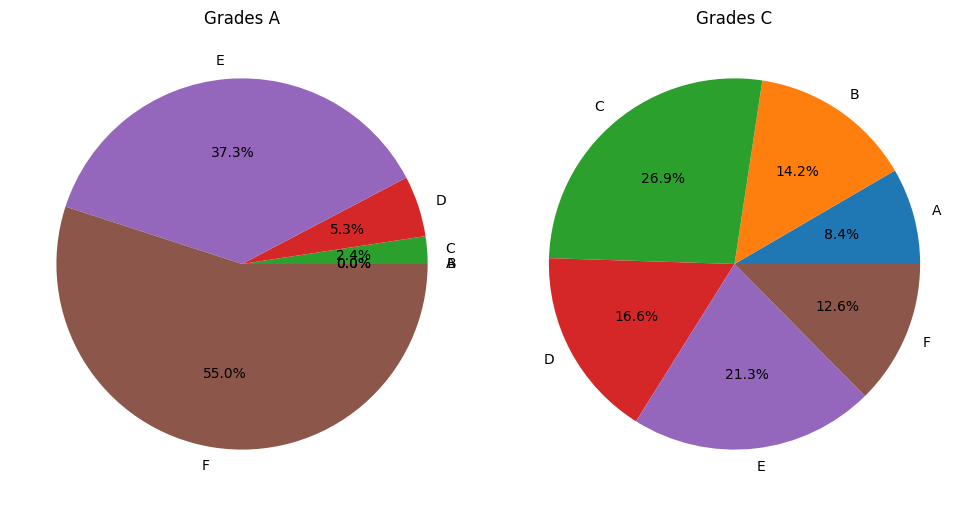

In [ ]:
import matplotlib.pyplot as plt

with open(f"{current_dir}/Data/NPvt19Ma2A.txt", "r") as file:
    data = [row.strip() for row in file if row.strip()]

    data_str = []
    data_per = []
    
    for line in data:
        grade, percent = line.split()
        data_str.append(grade)
        data_per.append(float(percent[:-1]))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].pie(data_per, labels=data_str, autopct="%1.1f%%")
    axes[0].set_title("Grades A")

with open(f"{current_dir}/Data/NPvt19Ma2C.txt", "r") as file:
    data = [row.strip() for row in file if row.strip()]

    data_str = []
    data_per = []
    
    for line in data:
        grade, percent = line.split()
        data_str.append(grade)
        data_per.append(float(percent[:-1]))

    axes[1].pie(data_per, labels=data_str, autopct="%1.1f%%")
    axes[1].set_title("Grades C")

    plt.tight_layout()
    plt.show()

---
## 4. Dice roll experiment (**)
Simulate 10, 100, 1000, 10000, 100000 dice rolls and count the freqencies and probabilities for each number in each simulation. Create a new text file using Python with the name "simulation.txt" and write the results to that text file.(**)

[files]: https://github.com/pr0fez/Programmering-med-Python-21/tree/master/Files

<details>

<summary>Answer </summary>

```

Number of rolls: 10 
Ones: 4, probability: 0.4
Twos: 1, probability: 0.1
Threes: 1, probability: 0.1
Fours: 2, probability: 0.2
Fives: 1, probability: 0.1
Sixes: 1, probability: 0.1

Number of rolls: 100 
Ones: 16, probability: 0.16
Twos: 12, probability: 0.12
Threes: 24, probability: 0.24
Fours: 18, probability: 0.18
Fives: 16, probability: 0.16
Sixes: 14, probability: 0.14

Number of rolls: 1000 
Ones: 181, probability: 0.181
Twos: 167, probability: 0.167
Threes: 184, probability: 0.184
Fours: 152, probability: 0.152
Fives: 168, probability: 0.168
Sixes: 148, probability: 0.148

Number of rolls: 10000 
Ones: 1630, probability: 0.163
Twos: 1666, probability: 0.1666
Threes: 1686, probability: 0.1686
Fours: 1616, probability: 0.1616
Fives: 1677, probability: 0.1677
Sixes: 1725, probability: 0.1725

Number of rolls: 100000 
Ones: 16804, probability: 0.16804
Twos: 16625, probability: 0.16625
Threes: 16646, probability: 0.16646
Fours: 16660, probability: 0.1666
Fives: 16576, probability: 0.16576
Sixes: 16689, probability: 0.16689

```

In [225]:
import numpy as np

dice_rolls = [10, 100, 1000, 10000, 100000, 1000000]

for rolls in dice_rolls:
    result = []
    print(f"Number of rolls: {rolls}")
    
    for i in range(rolls):
        result.append(np.random.randint(1,7))
    
    sides = ["Ones", "Twos", "Threes", "Fours", "Fives", "Sixes"]
    for i in range(6):
        count = result.count(i+1)
        probability = count / rolls
        print(f"{sides[i]}: {count}, probability: {probability}")
    print("")
    

Number of rolls: 10
Ones: 0, probability: 0.0
Twos: 2, probability: 0.2
Threes: 0, probability: 0.0
Fours: 2, probability: 0.2
Fives: 4, probability: 0.4
Sixes: 2, probability: 0.2

Number of rolls: 100
Ones: 15, probability: 0.15
Twos: 17, probability: 0.17
Threes: 19, probability: 0.19
Fours: 15, probability: 0.15
Fives: 14, probability: 0.14
Sixes: 20, probability: 0.2

Number of rolls: 1000
Ones: 171, probability: 0.171
Twos: 151, probability: 0.151
Threes: 178, probability: 0.178
Fours: 164, probability: 0.164
Fives: 168, probability: 0.168
Sixes: 168, probability: 0.168

Number of rolls: 10000
Ones: 1648, probability: 0.1648
Twos: 1627, probability: 0.1627
Threes: 1752, probability: 0.1752
Fours: 1624, probability: 0.1624
Fives: 1706, probability: 0.1706
Sixes: 1643, probability: 0.1643

Number of rolls: 100000
Ones: 16750, probability: 0.1675
Twos: 16702, probability: 0.16702
Threes: 16789, probability: 0.16789
Fours: 16418, probability: 0.16418
Fives: 16593, probability: 0.1659

---

pr0fez Giang

[LinkedIn][linkedIn_pr0fez]

[GitHub portfolio][github_portfolio]

[linkedIn_pr0fez]: https://www.linkedin.com/in/pr0fezgiang/
[github_portfolio]: https://github.com/pr0fez/Portfolio-pr0fez-Giang

---